# Age-Dependent Gene De-repression in Matrix D1 SPNs

Identifies genes that are **silenced in young donors** and progressively **re-expressed (de-repressed) with age**, using BICAN as a healthy-only reference cohort.

**Pipeline overview:**
1. Load NucSeq (XDP + Control) and BICAN (Control only) data
2. Subset to Matrix D1 cells in a specific zone
3. Detect candidate de-repressed genes using BICAN healthy donors only
4. Score all cells (XDP + Control) with an AUCell gene-set score
5. Test whether the de-repression score is driven by age, condition, or both

## Setup

In [1]:
%load_ext autoreload
%autoreload 2

import re
import os

import numpy as np
import pandas as pd
import scipy.sparse
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
import scanpy as sc
import decoupler as dc
import statsmodels.formula.api as smf
from statsmodels.stats.multitest import multipletests
from dotenv import load_dotenv

load_dotenv()

True

In [2]:
# ── Column names ──────────────────────────────────────────────────────────────
CT_FOR_DEG_VARIABLE = "ct_for_deg"   # cell-type annotation used for subsetting
SAMPLE_VARIABLE     = "donor_id"
CONTRAST_VARIABLE   = "condition"
CONTRAST_BASELINE   = "Control"
CONTRAST_STIM       = "XDP"
AGE                 = "age_of_death"
ZONE_COL            = "zone"
LIBRARY_SIZE_COL    = "total_counts"

# ── Covariates used in the statistical model ──────────────────────────────────
COVARIATES_FOR_DEG = ["sex", "pct_counts_mt"]

# ── Zone to analyse ───────────────────────────────────────────────────────────
ZONE = "4"

## Helper Functions

In [3]:
def merge_adata(adata_list):
    """
    Concatenate a list of AnnData objects keeping only the genes common to all
    (inner join on var_names). Preserves the 'gene_symbol' var column.
    """
    gene_sets    = [set(a.var_names) for a in adata_list]
    common_genes = set.intersection(*gene_sets)
    all_genes    = set.union(*gene_sets)
    print(f"[GENES] Common: {len(common_genes)} | Total: {len(all_genes)} "
          f"| Only-in-some: {len(all_genes) - len(common_genes)}")

    # Save var metadata before concat — sc.concat drops .var columns on inner join
    var_info = adata_list[0].var[["gene_symbol"]].copy()

    adata_combined = sc.concat(
        adata_list,
        join="inner",      # keep only common genes
        label=None,
        keys=None,
        index_unique=None  # obs_names are already unique
    )

    # Restore var metadata for the common genes
    adata_combined.var = var_info.loc[adata_combined.var_names]

    print(f"Combined shape: {adata_combined.shape} "
          f"({adata_combined.n_obs} cells × {adata_combined.n_vars} genes)")
    assert adata_combined.obs_names.is_unique, "ERROR: obs_names are not unique after concat!"

    del adata_list
    return adata_combined

In [4]:
def find_derepressed_genes(
    adata,

    # --- Required column names in adata.obs ---
    age_col          = "age",
    donor_col        = "donor_id",

    # --- Per-cell total UMI counts column in adata.obs ---
    # Used to compute mean log(UMI) per donor as a sequencing depth covariate.
    # Set to None to auto-detect from common names.
    counts_col       = None,

    # --- Other covariates (sex, ancestry PCs, etc.) ---
    other_covariate_cols = ["sex", "PC1", "PC2", "PC3", "PC4", "PC5"],

    # --- Detection threshold: max detection rate allowed in young donors ---
    threshold        = 0.05,

    # --- Age group definitions ---
    young_quantile   = 0.25,
    old_quantile     = 0.75,

    # --- Quality filters ---
    min_cells        = 30,
    fdr_threshold    = 0.05,
    exclude_pattern  = r"^MT-|^RPS\d|^RPL\d|^HB[^P]",

    # --- Permutation settings ---
    n_perm           = 10000,
    seed             = 42,
):
    """
    Identify genes that are silenced in young donors and significantly
    re-expressed (de-repressed) with age.

    Mirrors the logic of derepression_threshold_forward.py.

    Parameters
    ----------
    adata                : AnnData — cells × genes, raw counts in adata.X.
                           Filter to your cell type and zone BEFORE calling.
    age_col              : str  — per-cell donor age column
    donor_col            : str  — per-cell donor ID column
    counts_col           : str or None — per-cell total UMI column (auto-detected if None)
    other_covariate_cols : list — additional covariates (sex, PCs)
    threshold            : float — max detection rate defining "silent in young"
    young_quantile       : float — age quantile cutoff for "young" group
    old_quantile         : float — age quantile cutoff for "old" group
    min_cells            : int   — drop donors with fewer cells than this
    fdr_threshold        : float — BH-adjusted p-value cutoff
    exclude_pattern      : str   — regex of gene prefixes to always exclude
    n_perm               : int   — number of permutations
    seed                 : int   — random seed for reproducibility

    Returns
    -------
    pd.DataFrame with columns:
        gene, young_detect, old_detect, delta_detect, exceeds_in_old,
        obs_beta, perm_pval, perm_padj, significant
    """

    rng = np.random.RandomState(seed)

    # ── 0. Validate inputs and auto-detect counts column ──────────────────────
    check_cols = [age_col, donor_col] + other_covariate_cols
    missing = [c for c in check_cols if c not in adata.obs.columns]
    if missing:
        raise ValueError(f"Columns not found in adata.obs: {missing}")

    if counts_col is None:
        _candidates = ["n_counts", "total_counts", "nCounts", "nUMI", "n_umi", "total_UMI"]
        _found = [c for c in _candidates if c in adata.obs.columns]
        if not _found:
            raise ValueError(
                f"Could not auto-detect counts column. Tried: {_candidates}\n"
                f"Pass counts_col='your_column' explicitly."
            )
        counts_col = _found[0]
        print(f"Auto-detected counts column: '{counts_col}'")
    elif counts_col not in adata.obs.columns:
        raise ValueError(f"counts_col='{counts_col}' not found in adata.obs.")

    # ── 1. Prepare sparse count matrix ────────────────────────────────────────
    X = adata.X
    if not scipy.sparse.issparse(X):
        X = scipy.sparse.csr_matrix(X)
    elif not scipy.sparse.isspmatrix_csr(X):
        X = X.tocsr()

    donors_array = adata.obs[donor_col].values
    counts_array = adata.obs[counts_col].values.astype(float)
    gene_names   = adata.var_names.tolist()
    n_genes      = len(gene_names)

    # ── 2. Filter donors by minimum cell count ────────────────────────────────
    unique_donors, cell_counts = np.unique(donors_array, return_counts=True)
    donor_ncells = dict(zip(unique_donors, cell_counts))
    valid_donors = [d for d, n in donor_ncells.items() if n >= min_cells]
    n_dropped    = len(donor_ncells) - len(valid_donors)

    if n_dropped:
        print(f"Dropped {n_dropped} donors with < {min_cells} cells")
    if not valid_donors:
        raise ValueError("No donors passed the minimum cell count filter")

    # ── 3. Downsample all donors to the same number of cells ──────────────────
    # A donor with more cells detects more genes purely due to sampling.
    # Equalising cell counts removes this confound before computing detection rates.
    min_n = min(donor_ncells[d] for d in valid_donors)
    print(f"{len(valid_donors)} valid donors — downsampling each to {min_n} cells")

    # ── 4. Compute per-donor detection rates and mean log UMI ─────────────────
    detect_matrix = np.zeros((n_genes, len(valid_donors)), dtype=np.float32)
    mean_log_umi  = np.zeros(len(valid_donors),            dtype=np.float64)
    meta_rows     = []

    for j, donor in enumerate(valid_donors):
        cell_idx = np.where(donors_array == donor)[0]

        # Subsample to min_n
        if len(cell_idx) > min_n:
            cell_idx = rng.choice(cell_idx, size=min_n, replace=False)

        # Detection rate: fraction of subsampled cells with >= 1 count
        detected            = np.asarray((X[cell_idx, :] > 0).sum(axis=0)).ravel()
        detect_matrix[:, j] = detected / min_n

        # Sequencing depth covariate: mean log(UMI) across subsampled cells
        mean_log_umi[j] = np.log1p(counts_array[cell_idx]).mean()

        meta_rows.append(adata.obs[donors_array == donor].iloc[0])

    meta     = pd.DataFrame(meta_rows).reset_index(drop=True)
    n_donors = len(valid_donors)

    # ── 5. Define young and old donor groups ──────────────────────────────────
    ages       = meta[age_col].values.astype(float)
    q_young    = np.quantile(ages, young_quantile)
    q_old      = np.quantile(ages, old_quantile)
    young_mask = ages <= q_young
    old_mask   = ages >= q_old

    print(f"Young (age <= {q_young:.0f}): {young_mask.sum()} donors | "
          f"Old   (age >= {q_old:.0f}):   {old_mask.sum()} donors")

    young_detect = detect_matrix[:, young_mask].mean(axis=1)
    old_detect   = detect_matrix[:, old_mask].mean(axis=1)

    # ── 6. Select candidate genes ─────────────────────────────────────────────
    # Candidates: silent in young (mean detection <= threshold) + not housekeeping
    exclude_re   = re.compile(exclude_pattern)
    exclude_mask = np.array([bool(exclude_re.match(g)) for g in gene_names])

    candidate_mask = (young_detect <= threshold) & (~exclude_mask)
    n_candidates   = candidate_mask.sum()
    print(f"Candidate genes silent in young (threshold={threshold*100:.1f}%): {n_candidates}")

    if n_candidates == 0:
        raise ValueError(
            "No candidate genes found. Try:\n"
            "  - Increasing threshold (e.g. 0.05)\n"
            "  - Reducing min_cells to keep more donors\n"
            "  - Checking adata.X contains raw counts (not normalised)"
        )

    detect_cand = detect_matrix[candidate_mask, :]
    cand_genes  = [g for g, m in zip(gene_names, candidate_mask) if m]

    # ── 7. Build covariate matrix (intercept + depth + depth² + other covariates)
    # depth²  always included to capture non-linear sequencing depth effects
    cov_arrays = [
        np.ones(n_donors),
        mean_log_umi,
        mean_log_umi ** 2,
    ]
    for col in other_covariate_cols:
        raw = meta[col].values
        try:
            vals = raw.astype(float)
        except (ValueError, TypeError):
            # Encode categorical strings (e.g. 'F'/'M') as integers
            unique_vals = sorted(set(raw))
            mapping     = {v: i for i, v in enumerate(unique_vals)}
            vals        = np.array([mapping[v] for v in raw], dtype=float)
            print(f"Encoded '{col}': {mapping}")
        cov_arrays.append(vals)

    X_cov = np.column_stack(cov_arrays)
    Q, _  = np.linalg.qr(X_cov, mode="reduced")

    # ── 8. FWL residualisation ────────────────────────────────────────────────
    # Remove covariate effects from both age and detection rates before
    # computing the age slope (Frisch–Waugh–Lovell theorem).
    age_resid    = ages - Q @ (Q.T @ ages)
    ss_age       = np.sum(age_resid ** 2)

    if ss_age < 1e-12:
        # Diagnose which covariate is eating age variance
        print("\n--- COLLINEARITY DIAGNOSTIC ---")
        print(f"Age variance before residualisation: {np.var(ages):.4f}")
        for col_name, col_vec in zip(
            ["intercept", "mean_log_umi", "mean_log_umi²"] + other_covariate_cols,
            cov_arrays
        ):
            r = np.corrcoef(ages, col_vec)[0, 1]
            print(f"  corr(age, {col_name}) = {r:.4f}")
        raise ValueError(
            "No age variance after residualisation.\n"
            "Most likely cause: a covariate is perfectly predicted by age.\n"
            "Check the correlations above and remove the offending covariate."
        )

    detect_resid = detect_cand - (Q @ (Q.T @ detect_cand.T)).T
    obs_betas    = (detect_resid @ age_resid) / ss_age

    # ── 9. Permutation test (one-sided: detection increases with age) ─────────
    print(f"Running {n_perm} permutations ...", flush=True)

    perm_indices   = np.column_stack([rng.permutation(n_donors) for _ in range(n_perm)])
    age_perm_mat   = ages[perm_indices]
    age_resid_perm = age_perm_mat - Q @ (Q.T @ age_perm_mat)
    ss_perm        = np.sum(age_resid_perm ** 2, axis=0)

    beta_perm_mat  = (detect_resid @ age_resid_perm) / ss_perm
    perm_counts    = np.sum(beta_perm_mat >= obs_betas[:, np.newaxis], axis=1)
    perm_pvals     = (1 + perm_counts) / (1 + n_perm)

    # ── 10. BH FDR correction ─────────────────────────────────────────────────
    _, perm_padjs, _, _ = multipletests(perm_pvals, method="fdr_bh")

    # ── 11. Assemble results table ────────────────────────────────────────────
    results = pd.DataFrame({
        "gene"         : cand_genes,
        "young_detect" : young_detect[candidate_mask],
        "old_detect"   : old_detect[candidate_mask],
        "delta_detect" : old_detect[candidate_mask] - young_detect[candidate_mask],
        "exceeds_in_old": old_detect[candidate_mask] > threshold,
        "obs_beta"     : obs_betas,
        "perm_pval"    : perm_pvals,
        "perm_padj"    : perm_padjs,
        "significant"  : (perm_padjs < fdr_threshold) & (obs_betas > 0),
    }).sort_values("obs_beta", ascending=False).reset_index(drop=True)

    n_sig        = results["significant"].sum()
    n_sig_exceed = (results["significant"] & results["exceeds_in_old"]).sum()
    print(f"\nSignificant (padj < {fdr_threshold}): {n_sig}")
    print(f"  of which exceed threshold in old:   {n_sig_exceed}")
    print(f"\nTo relax significance:")
    print(f"  results[results['perm_pval'] < 0.05]   # skip FDR correction")
    print(f"  results[results['perm_padj'] < 0.10]   # 10% FDR")
    print(f"  re-run with threshold=0.05, min_cells=10")

    return results

---
## 1. Load Data

### 1.1 NucSeq — XDP Striatum (XDP + Control donors)

In [5]:
ADATA_PATH = "/home/gdallagl/myworkdir/XDP/data/XDP/NucSec/adatas/Striatum/Striatum_combined_QC_mmc_ct-cured_zoned.h5ad"
adata = sc.read_h5ad(ADATA_PATH, backed="r")

# Use gene symbols as var_names (rather than Ensembl IDs)
adata.var.index = adata.var["gene_symbol"]

# Normalise cell-type labels (replace spaces with underscores)
adata.obs[CT_FOR_DEG_VARIABLE] = adata.obs[CT_FOR_DEG_VARIABLE].str.replace(" ", "_")

print(adata)

AnnData object with n_obs × n_vars = 231080 × 38601 backed at '/home/gdallagl/myworkdir/XDP/data/XDP/NucSec/adatas/Striatum/Striatum_combined_QC_mmc_ct-cured_zoned.h5ad'
    obs: 'background_fraction', 'cell_probability', 'cell_size', 'droplet_efficiency', 'barcode', 'bcl', 'rna_index', 'library', 'library__barcode', 'frac_mito', 'mol_info_nUMI', 'mol_info_nRead', 'frac_intronic', 'donor_id', 'vireo_prob_max', 'vireo_prob_doublet', 'vireo_n_vars', 'vireo_best_singlet', 'vireo_best_doublet', 'vireo_doublet_logLikRatio', 'dropsift_frac_contamination', 'dropsift_training_label_is_cell', 'dropsift_empty_gene_module_score', 'dropsift_is_cell', 'dropsift_is_cell_prob', 'cell_class', 'leiden_0.1', 'leiden_0.2', 'leiden_0.3', 'leiden_0.4', 'leiden_0.5', 'tissue', 'broad_original_cell_type', 'n_genes_by_counts', 'log1p_n_genes_by_counts', 'total_counts', 'log1p_total_counts', 'pct_counts_in_top_50_genes', 'pct_counts_in_top_100_genes', 'pct_counts_in_top_200_genes', 'pct_counts_in_top_500_genes

### 1.2 BICAN — Healthy Reference (Control only)

In [6]:
bican = sc.read_h5ad(
    "/home/gdallagl/myworkdir/XDP/data/BICAN/d1_cleaner_v3_raw_dv_wm_labeled.h5ad",
    backed="r"
)

# Rename columns to match NucSeq conventions
bican.obs = bican.obs.rename(columns={
    "merge_step_6" : ZONE_COL,
    "donor_id"     : SAMPLE_VARIABLE,
    "age"          : AGE,
    "n_counts"     : LIBRARY_SIZE_COL,
    "imputed_sex"  : "sex",
})

# All BICAN donors are healthy controls
bican.obs[CONTRAST_VARIABLE] = CONTRAST_BASELINE

# Covariates available in BICAN (sex + first 5 ancestry PCs)
bican_cov = ["sex", "PC1", "PC2", "PC3", "PC4", "PC5"]

print(bican)

AnnData object with n_obs × n_vars = 206571 × 38100 backed at '/home/gdallagl/myworkdir/XDP/data/BICAN/d1_cleaner_v3_raw_dv_wm_labeled.h5ad'
    obs: 'prefix', 'cell_barcode', 'expression_doublet', 'num_genic_reads', 'num_transcripts', 'num_genes', 'num_retained_transcripts', 'pct_coding', 'pct_utr', 'pct_intergenic', 'pct_intronic', 'pct_mt', 'frac_contamination', 'donor_external_id', 'biobank', 'cohort', 'age_of_death', 'race', 'pmi_hr', 'sex', 'eur_adj', 'afr_adj', 'nat_adj', 'eas_adj', 'sas_adj', 'PC1', 'PC2', 'PC3', 'PC4', 'PC5', 'toxicology_group', 'toxicology_report_complete', 'toxicology_compounds_detected', 'hbcac_status', 'experiment', 'scpred_cortex_class', 'scpred_cortex_class_max_prob', 'scpred_cortex_gaba_sub_class', 'scpred_cortex_gaba_sub_class_max_prob', 'scpred_cortex_glut_sub_class', 'scpred_cortex_glut_sub_class_max_prob', 'scpred_caudate_class', 'scpred_caudate_class_max_prob', 'scpred_caudate_spn_di', 'scpred_caudate_spn_di_max_prob', 'scpred_caudate_spn_en', 'scp

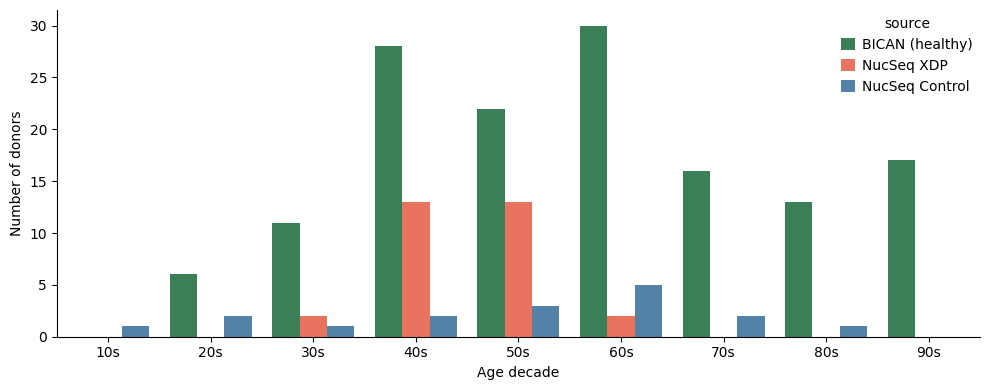

In [10]:
import seaborn as sns

df_donors_bican = bican.obs.drop_duplicates(subset='donor_id').copy()
df_donors       = adata.obs.drop_duplicates(subset='donor_id').copy()

df_donors_bican['source'] = 'BICAN (healthy)'
df_donors['source'] = df_donors[CONTRAST_VARIABLE].map({
    CONTRAST_BASELINE: 'NucSeq Control',
    CONTRAST_STIM:     'NucSeq XDP',
})

df_merged = pd.concat([
    df_donors_bican[[AGE, 'source']],
    df_donors[[AGE, 'source']],
])
df_merged[AGE] = df_merged[AGE].astype(float)
df_merged = df_merged.dropna(subset=[AGE])
df_merged['age_decade'] = (df_merged[AGE] // 10 * 10).astype(int).astype(str) + 's'

decade_order = sorted(df_merged['age_decade'].unique())

palette = {
    'BICAN (healthy)': 'seagreen',
    'NucSeq XDP':      'tomato',
    'NucSeq Control':  'steelblue',
}

fig, ax = plt.subplots(figsize=(10, 4))
sns.countplot(
    data=df_merged, x='age_decade', hue='source',
    order=decade_order, palette=palette, ax=ax,
)
ax.set_xlabel('Age decade')
ax.set_ylabel('Number of donors')
sns.despine()
plt.tight_layout()
plt.show()


---
## 2. Analysis — Matrix D1 SPNs, Zone 4

### 2.1 Subset Cells

In [11]:
# ── NucSeq: Matrix D1, zone 4, loaded into memory ─────────────────────────────
adata_zone = adata[
    (adata.obs[CT_FOR_DEG_VARIABLE] == "Matrix_D1") &
    (adata.obs[ZONE_COL] == ZONE)
].to_memory().copy()

# ── BICAN: zone 4 (stored as integer) ─────────────────────────────────────────
bican_zone = bican[bican.obs[ZONE_COL] == int(ZONE)].to_memory().copy()

print(f"NucSeq zone {ZONE}: {adata_zone.n_obs} cells, {adata_zone.obs[SAMPLE_VARIABLE].nunique()} donors")
print(f"BICAN   zone {ZONE}: {bican_zone.n_obs} cells, {bican_zone.obs[SAMPLE_VARIABLE].nunique()} donors")

NucSeq zone 4: 1280 cells, 43 donors
BICAN   zone 4: 88688 cells, 142 donors


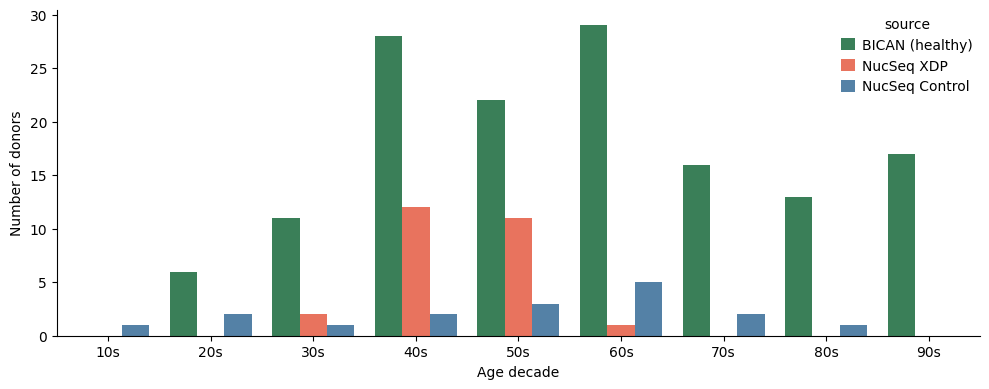

In [13]:
import seaborn as sns

df_donors_bican = bican_zone.obs.drop_duplicates(subset='donor_id').copy()
df_donors       = adata_zone.obs.drop_duplicates(subset='donor_id').copy()

df_donors_bican['source'] = 'BICAN (healthy)'
df_donors['source'] = df_donors[CONTRAST_VARIABLE].map({
    CONTRAST_BASELINE: 'NucSeq Control',
    CONTRAST_STIM:     'NucSeq XDP',
})

df_merged = pd.concat([
    df_donors_bican[[AGE, 'source']],
    df_donors[[AGE, 'source']],
])
df_merged[AGE] = df_merged[AGE].astype(float)
df_merged['age_decade'] = (df_merged[AGE] // 10 * 10).astype(int).astype(str) + 's'

# Keep only decades present in the data, sorted
decade_order = sorted(df_merged['age_decade'].unique())

palette = {
    'BICAN (healthy)': 'seagreen',
    'NucSeq XDP':      'tomato',
    'NucSeq Control':  'steelblue',
}

fig, ax = plt.subplots(figsize=(10, 4))
sns.countplot(
    data=df_merged, x='age_decade', hue='source',
    order=decade_order, palette=palette, ax=ax,
)
ax.set_xlabel('Age decade')
ax.set_ylabel('Number of donors')
sns.despine()
plt.tight_layout()
plt.show()


In [14]:
# Remove donors with fewer than N cells (too noisy for detection-rate estimates)
MIN_CELLS_PER_DONOR = 10

def filter_low_cell_donors(adata, sample_col, min_cells):
    counts    = adata.obs[sample_col].value_counts()
    keep      = counts[counts >= min_cells].index
    return adata[adata.obs[sample_col].isin(keep)].copy()

adata_zone = filter_low_cell_donors(adata_zone, SAMPLE_VARIABLE, MIN_CELLS_PER_DONOR)
bican_zone = filter_low_cell_donors(bican_zone, SAMPLE_VARIABLE, MIN_CELLS_PER_DONOR)

print(f"After filtering — NucSeq: {adata_zone.obs[SAMPLE_VARIABLE].nunique()} donors")
print(f"After filtering — BICAN:  {bican_zone.obs[SAMPLE_VARIABLE].nunique()} donors")

After filtering — NucSeq: 35 donors
After filtering — BICAN:  139 donors


### Check how many sample we have for this ct x zone in the 2 df

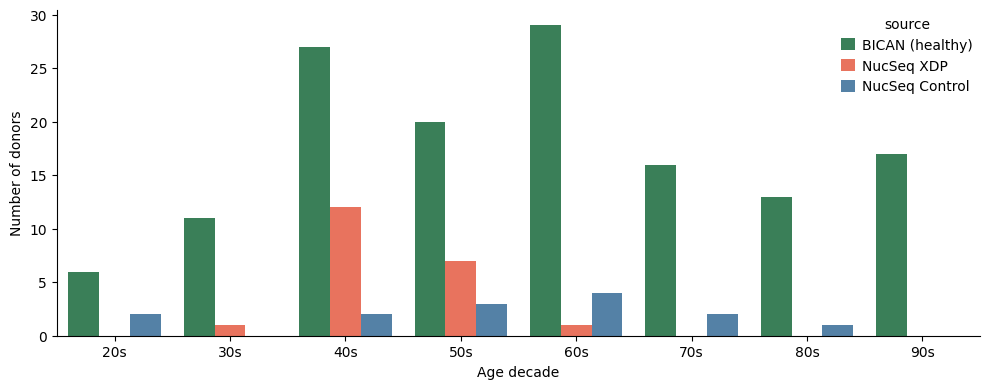

In [15]:
import seaborn as sns

df_donors_bican = bican_zone.obs.drop_duplicates(subset='donor_id').copy()
df_donors       = adata_zone.obs.drop_duplicates(subset='donor_id').copy()

df_donors_bican['source'] = 'BICAN (healthy)'
df_donors['source'] = df_donors[CONTRAST_VARIABLE].map({
    CONTRAST_BASELINE: 'NucSeq Control',
    CONTRAST_STIM:     'NucSeq XDP',
})

df_merged = pd.concat([
    df_donors_bican[[AGE, 'source']],
    df_donors[[AGE, 'source']],
])
df_merged[AGE] = df_merged[AGE].astype(float)
df_merged['age_decade'] = (df_merged[AGE] // 10 * 10).astype(int).astype(str) + 's'

# Keep only decades present in the data, sorted
decade_order = sorted(df_merged['age_decade'].unique())

palette = {
    'BICAN (healthy)': 'seagreen',
    'NucSeq XDP':      'tomato',
    'NucSeq Control':  'steelblue',
}

fig, ax = plt.subplots(figsize=(10, 4))
sns.countplot(
    data=df_merged, x='age_decade', hue='source',
    order=decade_order, palette=palette, ax=ax,
)
ax.set_xlabel('Age decade')
ax.set_ylabel('Number of donors')
sns.despine()
plt.tight_layout()
plt.show()


... storing 'ct_for_deg' as categorical


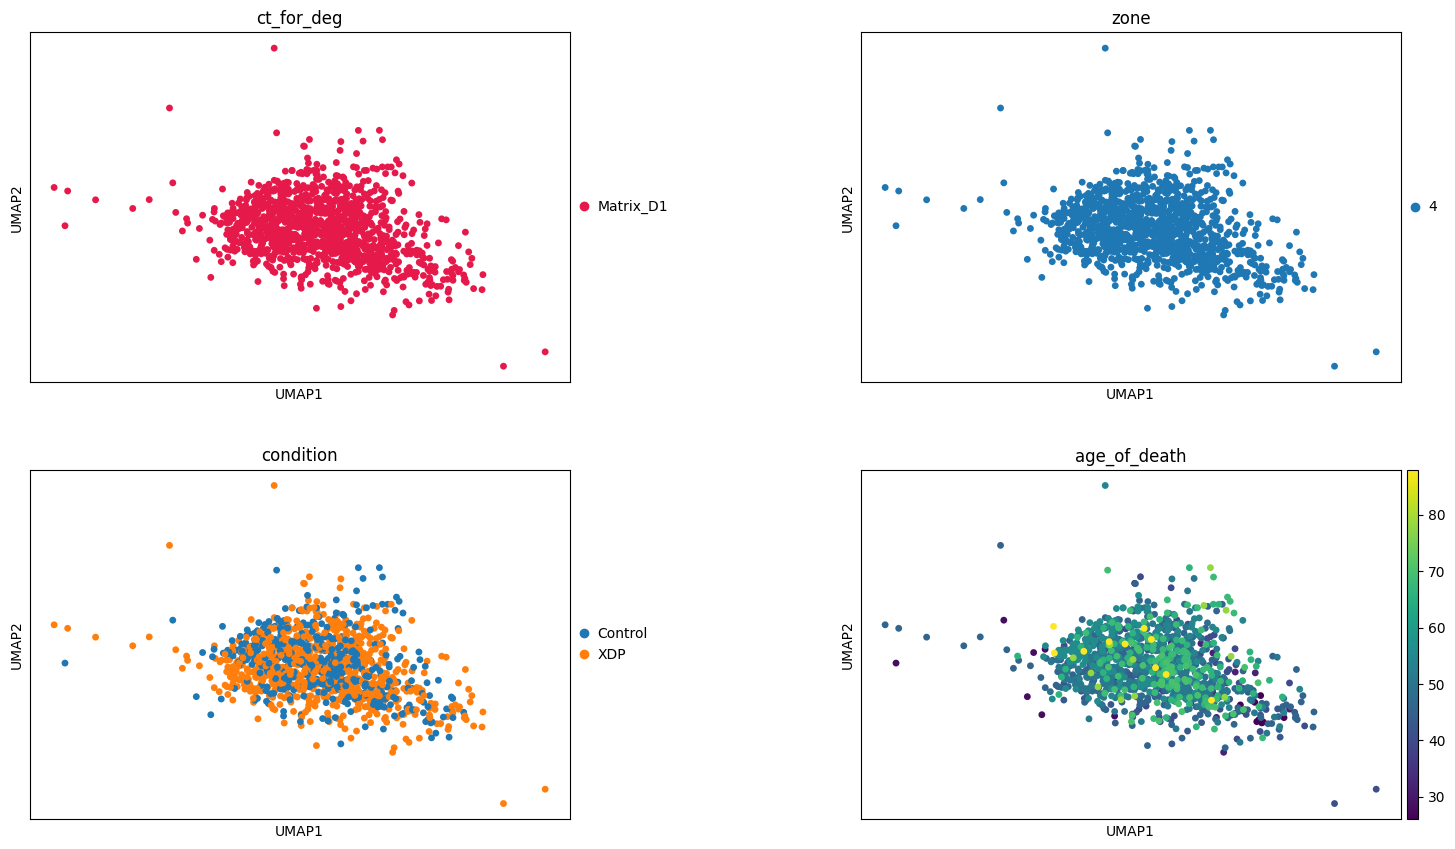

In [16]:
# Quick visual sanity check on NucSeq data
sc.pl.umap(
    adata_zone,
    color  = [CT_FOR_DEG_VARIABLE, ZONE_COL, CONTRAST_VARIABLE, AGE],
    wspace = 0.4,
    ncols  = 2,
)

### 2.2 Find De-repressed Genes (BICAN healthy donors only)

We use BICAN exclusively here so that XDP pathology cannot inflate the candidate list.

In [18]:
results = find_derepressed_genes(
    bican_zone,
    age_col              = AGE,
    donor_col            = SAMPLE_VARIABLE,
    counts_col           = LIBRARY_SIZE_COL,
    other_covariate_cols = bican_cov,
    threshold            = 0.02,
)

display(results)

Dropped 5 donors with < 30 cells
134 valid donors — downsampling each to 31 cells
Young (age <= 48): 37 donors | Old   (age >= 76):   35 donors
Candidate genes silent in young (threshold=2.0%): 14050
Running 10000 permutations ...

Significant (padj < 0.05): 86
  of which exceed threshold in old:   25

To relax significance:
  results[results['perm_pval'] < 0.05]   # skip FDR correction
  results[results['perm_padj'] < 0.10]   # 10% FDR
  re-run with threshold=0.05, min_cells=10


,gene,young_detect,old_detect,delta_detect,exceeds_in_old,obs_beta,perm_pval,perm_padj,significant
0,TMEM26-AS1,0.013949,0.066359,0.052410,True,0.001393,0.000100,0.024647,True
1,ENSG00000287227,0.019180,0.077419,0.058239,True,0.001058,0.000400,0.054558,False
2,ENSG00000270114,0.019180,0.053456,0.034276,True,0.001020,0.000100,0.024647,True
3,HSD17B11,0.016565,0.063594,0.047030,True,0.001011,0.000100,0.024647,True
4,LINC01016,0.017437,0.051613,0.034176,True,0.001001,0.006999,0.216132,False
...,...,...,...,...,...,...,...,...,...
14045,ENSG00000267462,0.012206,0.003687,-0.008519,False,-0.000285,0.999900,1.000000,False
14046,PPP1R3D,0.016565,0.005530,-0.011035,False,-0.000286,0.998200,1.000000,False
14047,ENSG00000281920,0.013949,0.000922,-0.013028,False,-0.000317,1.000000,1.000000,False
14048,ENSG00000258443,0.019180,0.005530,-0.013651,False,-0.000330,1.000000,1.000000,False


### 2.3 Age Matching

Optionally align the two cohorts by age so that BICAN and NucSeq Control donors cover
a similar age range as the XDP donors.

- **`MATCH_BICAN_AGE_RANGE`** — keep only BICAN donors within the XDP age range `[min_xdp, max_xdp]`
- **`REMOVE_FAR_CONTROLS`** — drop NucSeq Control donors whose age falls more than `AGE_MARGIN` years outside the XDP range

XDP age range: 32–66, n=21 donors
XDP donors per decade:
 decade
30     1
40    12
50     7
60     1
dtype: int64

[NucSeq Controls] 14 → 8 donors after age-matching
[NucSeq XDP]      21 donors (untouched)

[BICAN]           139 → 25 donors after age-matching


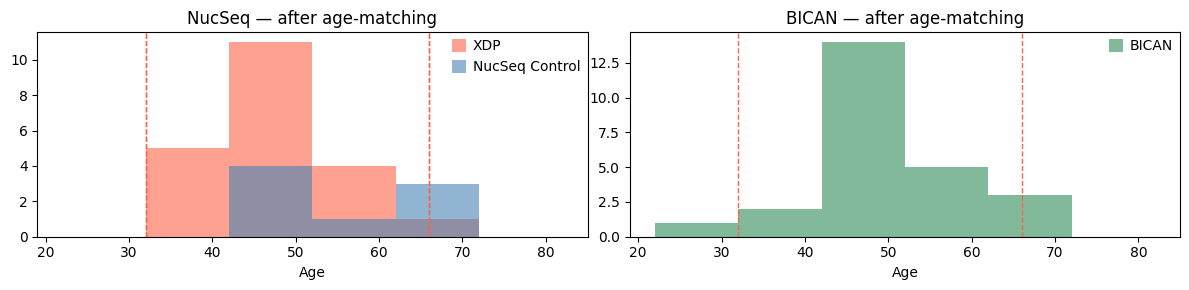


Final — NucSeq: 29 donors | BICAN: 25 donors


In [19]:
# ── XDP age range (never touched) ────────────────────────────────────────────
xdp_donor_meta = (
    adata_zone.obs[adata_zone.obs[CONTRAST_VARIABLE] == CONTRAST_STIM]
    .drop_duplicates(SAMPLE_VARIABLE)
    [[SAMPLE_VARIABLE, AGE]]
    .assign(**{AGE: lambda df: df[AGE].astype(float)})
)
xdp_age_min = xdp_donor_meta[AGE].min()
xdp_age_max = xdp_donor_meta[AGE].max()

# XDP donors per 10-year bin — this is the cap for healthy donors
xdp_donor_meta["decade"] = (xdp_donor_meta[AGE] // 10 * 10).astype(int)
xdp_per_decade = xdp_donor_meta.groupby("decade").size()

print(f"XDP age range: {xdp_age_min:.0f}–{xdp_age_max:.0f}, n={len(xdp_donor_meta)} donors")
print("XDP donors per decade:\n", xdp_per_decade)


# ── Helper: downsample healthy donors to match XDP density per decade ─────────
AGE_BUFFER   = 5    # years of tolerance beyond [xdp_age_min, xdp_age_max]
MIN_HEALTHY  = 3    # minimum healthy donors to keep per decade (if available)

def downsample_healthy(donor_meta, age_col, sample_col, age_min, age_max,
                        xdp_per_decade, age_buffer=AGE_BUFFER,
                        min_keep=MIN_HEALTHY, seed=42):
    """
    1. Remove donors whose age falls outside [age_min - age_buffer, age_max + age_buffer].
    2. Per 10-year bin, keep at most max(n_xdp, min_keep) donors
       (bins with 0 XDP donors are dropped entirely unless min_keep applies).
    Returns a set of donor IDs to keep.
    """
    rng  = np.random.RandomState(seed)
    meta = donor_meta.copy()
    meta[age_col] = meta[age_col].astype(float)

    # Step 1: restrict to XDP age range ± buffer
    in_range = meta[
        (meta[age_col] >= age_min - age_buffer) &
        (meta[age_col] <= age_max + age_buffer)
    ].copy()

    # Step 2: per-decade downsampling
    in_range["decade"] = (in_range[age_col] // 10 * 10).astype(int)

    keep_ids = []
    for decade, grp in in_range.groupby("decade"):
        n_xdp = xdp_per_decade.get(decade, 0)
        if n_xdp == 0:
            continue          # no XDP in this bin → drop all healthy here
        n_target = max(n_xdp, min_keep)
        if len(grp) <= n_target:
            keep_ids.extend(grp[sample_col].tolist())
        else:
            keep_ids.extend(
                rng.choice(grp[sample_col].values, size=n_target, replace=False).tolist()
            )

    return set(keep_ids)


# ── Apply to NucSeq Controls (XDP left untouched) ────────────────────────────
nucseq_ctrl_meta = (
    adata_zone.obs[adata_zone.obs[CONTRAST_VARIABLE] == CONTRAST_BASELINE]
    .drop_duplicates(SAMPLE_VARIABLE)
    [[SAMPLE_VARIABLE, AGE]]
)
n_ctrl_before = len(nucseq_ctrl_meta)
keep_ctrl = downsample_healthy(
    nucseq_ctrl_meta, AGE, SAMPLE_VARIABLE, xdp_age_min, xdp_age_max, xdp_per_decade
)

xdp_ids     = set(xdp_donor_meta[SAMPLE_VARIABLE])
keep_nucseq = xdp_ids | keep_ctrl
adata_zone  = adata_zone[adata_zone.obs[SAMPLE_VARIABLE].isin(keep_nucseq)].copy()

print(f"\n[NucSeq Controls] {n_ctrl_before} → {len(keep_ctrl)} donors after age-matching")
print(f"[NucSeq XDP]      {len(xdp_ids)} donors (untouched)")

# ── Apply to BICAN (all healthy) ──────────────────────────────────────────────
bican_donor_meta = (
    bican_zone.obs
    .drop_duplicates(SAMPLE_VARIABLE)
    [[SAMPLE_VARIABLE, AGE]]
)
n_bican_before = len(bican_donor_meta)
keep_bican = downsample_healthy(
    bican_donor_meta, AGE, SAMPLE_VARIABLE, xdp_age_min, xdp_age_max, xdp_per_decade
)
bican_zone = bican_zone[bican_zone.obs[SAMPLE_VARIABLE].isin(keep_bican)].copy()

print(f"\n[BICAN]           {n_bican_before} → {len(keep_bican)} donors after age-matching")

# ── Summary plot ──────────────────────────────────────────────────────────────
bins = np.arange(xdp_age_min - AGE_BUFFER - 5, xdp_age_max + AGE_BUFFER + 15, 10)
fig, axes = plt.subplots(1, 2, figsize=(12, 3), sharey=False)

ctrl_ages_after  = (
    adata_zone.obs[adata_zone.obs[CONTRAST_VARIABLE] == CONTRAST_BASELINE]
    .drop_duplicates(SAMPLE_VARIABLE)[AGE].astype(float)
)
bican_ages_after = bican_zone.obs.drop_duplicates(SAMPLE_VARIABLE)[AGE].astype(float)

for ax, ages_s, label, color in [
    (axes[0], xdp_donor_meta[AGE], "XDP",           "tomato"),
    (axes[0], ctrl_ages_after,      "NucSeq Control","steelblue"),
    (axes[1], bican_ages_after,     "BICAN",         "seagreen"),
]:
    ax.hist(ages_s, bins=bins, alpha=0.6, label=label, color=color)
    ax.axvline(xdp_age_min, color="tomato", linestyle="--", linewidth=1)
    ax.axvline(xdp_age_max, color="tomato", linestyle="--", linewidth=1)
    ax.set_xlabel("Age")
    ax.legend()

axes[0].set_title("NucSeq — after age-matching")
axes[1].set_title("BICAN — after age-matching")
plt.tight_layout()
plt.show()

print(f"\nFinal — NucSeq: {adata_zone.obs[SAMPLE_VARIABLE].nunique()} donors | "
      f"BICAN: {bican_zone.obs[SAMPLE_VARIABLE].nunique()} donors")

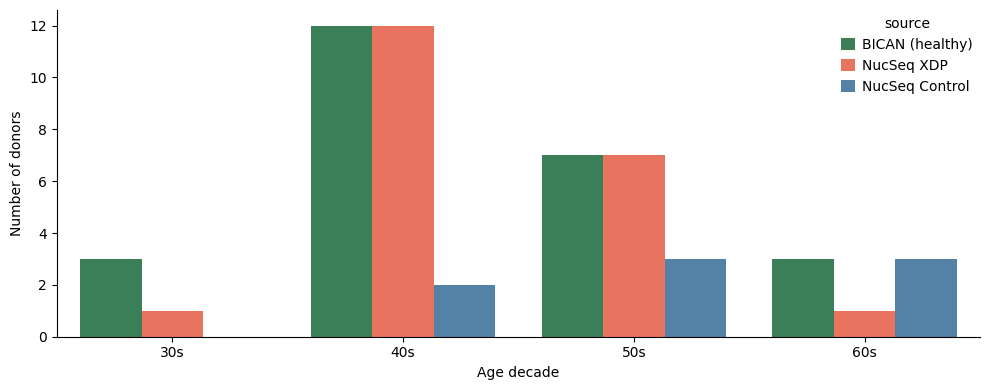

In [20]:
import seaborn as sns

df_donors_bican = bican_zone.obs.drop_duplicates(subset='donor_id').copy()
df_donors       = adata_zone.obs.drop_duplicates(subset='donor_id').copy()

df_donors_bican['source'] = 'BICAN (healthy)'
df_donors['source'] = df_donors[CONTRAST_VARIABLE].map({
    CONTRAST_BASELINE: 'NucSeq Control',
    CONTRAST_STIM:     'NucSeq XDP',
})

df_merged = pd.concat([
    df_donors_bican[[AGE, 'source']],
    df_donors[[AGE, 'source']],
])
df_merged[AGE] = df_merged[AGE].astype(float)
df_merged['age_decade'] = (df_merged[AGE] // 10 * 10).astype(int).astype(str) + 's'

# Keep only decades present in the data, sorted
decade_order = sorted(df_merged['age_decade'].unique())

palette = {
    'BICAN (healthy)': 'seagreen',
    'NucSeq XDP':      'tomato',
    'NucSeq Control':  'steelblue',
}

fig, ax = plt.subplots(figsize=(10, 4))
sns.countplot(
    data=df_merged, x='age_decade', hue='source',
    order=decade_order, palette=palette, ax=ax,
)
ax.set_xlabel('Age decade')
ax.set_ylabel('Number of donors')
sns.despine()
plt.tight_layout()
plt.show()


---
## 3. Score Cells with AUCell

Score every cell (XDP + BICAN) with the de-repressed gene set identified above.

### 3.1 Normalise Both Datasets

In [21]:
def normalize_adata(adata):
    """In-place: normalize → log1p → store in layers['log1p_norm'], restore raw counts to X."""
    adata.X = adata.layers["counts"]
    sc.pp.normalize_total(adata, target_sum=1e4)
    sc.pp.log1p(adata)
    adata.layers["log1p_norm"] = adata.X.copy()
    adata.X = adata.layers["counts"]

normalize_adata(adata_zone)
normalize_adata(bican_zone)

### 3.2 Merge Datasets and Compute AUCell Score

In [22]:
# Tag each dataset so we can trace cell origin after concatenation
adata_zone.obs["dataset"] = "NucSeq"
bican_zone.obs["dataset"] = "BICAN"

full_adata = merge_adata([adata_zone, bican_zone])

print("\nCells per dataset:")
print(full_adata.obs["dataset"].value_counts())
print(full_adata)

[GENES] Common: 35563 | Total: 41138 | Only-in-some: 5575
Combined shape: (11894, 35563) (11894 cells × 35563 genes)

Cells per dataset:
dataset
BICAN     10825
NucSeq     1069
Name: count, dtype: int64
AnnData object with n_obs × n_vars = 11894 × 35563
    obs: 'donor_id', 'total_counts', 'cohort', 'condition', 'sex', 'age_of_death', 'zone', 'dataset'
    var: 'gene_symbol'
    layers: 'counts', 'log1p_norm'


2026-03-13 01:38:36 | [INFO] aucell - Running aucell


Significant de-repressed genes: 86


2026-03-13 01:38:36 | [INFO] Extracted omics mat with 11894 rows (observations) and 35563 columns (features)
2026-03-13 01:38:37 | [WARNING] 1840 features of mat are empty, they will be removed
2026-03-13 01:38:40 | [INFO] Network has 73 unique features and 1 unique sources
2026-03-13 01:38:40 | [INFO] aucell - calculating 1 AUCs for 33723 targets across 11894 observations, categorizing features at rank=17781


  0%|          | 0/11894 [00:00<?, ?it/s]

2026-03-13 01:46:53 | [INFO] aucell - done


AUCell scores saved to: /home/gdallagl/myworkdir/XDP/data/_old/derepressed_score_zone4.csv


<Axes: title={'center': 'De-repression score distribution'}, ylabel='Frequency'>

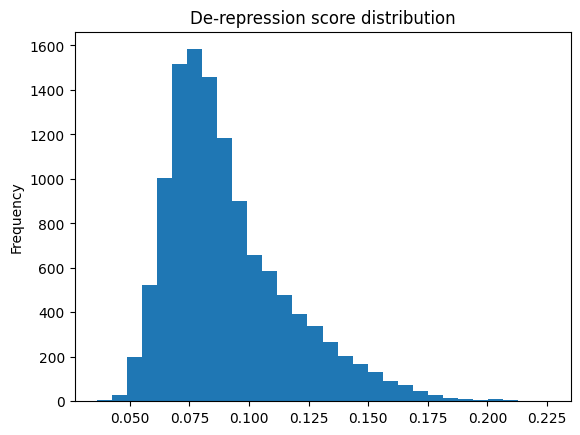

In [24]:
import os

AUCELL_CACHE = f"/home/gdallagl/myworkdir/XDP/data/_old/derepressed_score_zone{ZONE}.csv"

if os.path.exists(AUCELL_CACHE):
    # ── Load from cache ───────────────────────────────────────────────────────
    cached = pd.read_csv(AUCELL_CACHE, index_col=0)
    full_adata.obs["derepressed_score"] = cached.loc[full_adata.obs_names, "derepressed_score"].values
    print(f"Loaded AUCell scores from cache: {AUCELL_CACHE}")

else:
    # ── Run AUCell and save ───────────────────────────────────────────────────
    sig_genes = results[results["significant"]]["gene"].tolist()
    print(f"Significant de-repressed genes: {len(sig_genes)}")

    net = pd.DataFrame({
        "source" : "derepressed",
        "target" : sig_genes,
        "weight" : 1.0,
    })

    dc.mt.aucell(
        data   = full_adata,
        net    = net,
        tmin   = 3,
        n_up   = full_adata.n_vars // 2,
        layer  = "log1p_norm",
        raw    = False,
        bsize  = 250000,
        verbose= True,
    )

    full_adata.obs["derepressed_score"] = full_adata.obsm["score_aucell"]["derepressed"].values

    # Save only the score column (lightweight)
    full_adata.obs[["derepressed_score"]].to_csv(AUCELL_CACHE)
    print(f"AUCell scores saved to: {AUCELL_CACHE}")

full_adata.obs["derepressed_score"].plot.hist(bins=30, title="De-repression score distribution")


---
## 4. Donor-Level Summary

In [33]:
# Aggregate per-cell scores to one row per donor
summary = (
    full_adata.obs
    .groupby(SAMPLE_VARIABLE, observed=True)
    .agg(
        pct90_derepressed = ("derepressed_score", lambda x: np.percentile(x, 90)),
        age               = (AGE, "first"),
        median_umi        = (LIBRARY_SIZE_COL, "median"),
        condition         = (CONTRAST_VARIABLE, "first"),
    )
    .reset_index()
)

summary["age_scaled"] = (summary["age"] - summary["age"].mean()) / summary["age"].std()
summary["median_umi_scaled"] = (summary["median_umi"] - summary["median_umi"].mean()) / summary["median_umi"].std()


display(summary)
summary["condition"].value_counts()

,donor_id,pct90_derepressed,age,median_umi,condition,age_scaled,median_umi_scaled
0,MD6366,0.109354,31.0,140029.0,Control,-2.034175,1.091793
1,MD6417,0.103116,46.0,143619.0,Control,-0.363098,1.172174
2,MD6433,0.087921,47.0,150268.0,Control,-0.251693,1.321046
3,MD6592,0.133027,53.0,119257.5,Control,0.416738,0.626714
4,MD9081,0.106490,37.0,110362.0,Control,-1.365744,0.427542
5,MD9085,0.107723,59.0,105366.0,Control,1.085168,0.315680
6,MD9168,0.108737,43.0,96836.5,Control,-0.697314,0.124703
7,MD9237,0.159787,42.0,100730.0,Control,-0.808719,0.211879
8,MDUMBN6927,0.100468,48.0,106940.5,Control,-0.140288,0.350934
9,MLS05283,0.120957,48.0,138852.0,Control,-0.140288,1.065439


condition
Control    33
XDP        21
Name: count, dtype: int64

---
## 5. Statistical Analysis — OLS Regression

Test whether the de-repression score increases with **age**, accounting for
**condition** (XDP vs Control) and **sequencing depth** (median UMI).

The interaction term `age × is_xdp` captures whether the age trajectory differs
between XDP and Control donors.

In [28]:
# Encode condition as a binary indicator (XDP = 1, Control = 0)
summary["is_xdp"] = (summary["condition"] == "XDP").astype(int)

model = smf.ols(
    "pct90_derepressed ~ age_scaled * is_xdp + median_umi_scaled",
    data=summary
).fit()

print(model.summary())

                            OLS Regression Results                            
Dep. Variable:      pct90_derepressed   R-squared:                       0.765
Model:                            OLS   Adj. R-squared:                  0.745
Method:                 Least Squares   F-statistic:                     39.77
Date:                Fri, 13 Mar 2026   Prob (F-statistic):           8.09e-15
Time:                        01:48:44   Log-Likelihood:                 154.66
No. Observations:                  54   AIC:                            -299.3
Df Residuals:                      49   BIC:                            -289.4
Df Model:                           4                                         
Covariance Type:            nonrobust                                         
                        coef    std err          t      P>|t|      [0.025      0.975]
-------------------------------------------------------------------------------------
Intercept             0.1290      0.00

In [29]:
# ── Partial correlation: age effect controlling for condition + UMI ────────────
resid_age   = smf.ols("age_scaled ~ is_xdp + median_umi_scaled",               data=summary).fit().resid
resid_score = smf.ols("pct90_derepressed ~ is_xdp + median_umi_scaled", data=summary).fit().resid
partial_r   = np.corrcoef(resid_age, resid_score)[0, 1]
print(f"Partial r (age_scaled effect, controlling for condition + UMI): {partial_r:.3f}")

print()

# ── Partial correlation separately per condition ──────────────────────────────
# Tells you how strong the age trend is within each group independently.
for cond, grp in summary.groupby("condition", observed=True):
    resid_age_g   = smf.ols("age_scaled ~ median_umi_scaled",               data=grp).fit().resid
    resid_score_g = smf.ols("pct90_derepressed ~ median_umi_scaled", data=grp).fit().resid
    r = np.corrcoef(resid_age_g, resid_score_g)[0, 1]
    print(f"Partial r in {cond}: {r:.3f}  (n={len(grp)} donors)")

Partial r (age_scaled effect, controlling for condition + UMI): 0.061

Partial r in Control: 0.061  (n=33 donors)
Partial r in XDP: 0.015  (n=21 donors)


In [36]:
summary.groupby(CONTRAST_VARIABLE)[["median_umi"]].describe()


median_umi                                                           \
               count           mean           std      min      25%       50%   
condition                                                                       
Control         33.0  101643.590909  34329.254984  22294.0  89988.0  106940.5   
XDP             21.0   74960.857143  54254.773410  21278.0  30957.0   36586.5   

                               
                75%       max  
condition                      
Control    123398.5  150268.0  
XDP        127882.0  172314.5

In [ ]:
"""
XDP donors have ~3× lower sequencing depth than Controls. 
And since your de-repression score goes up when UMI goes down (coef = -0.025), 
the apparent XDP enrichment in the boxplot was almost entirely driven by XDP being more shallowly sequenced — not biology.
"""

---
## 6. Visualization — De-repression Score by Age Decade and Condition

Each box = one donor. Donors are grouped by age decade and coloured by condition.

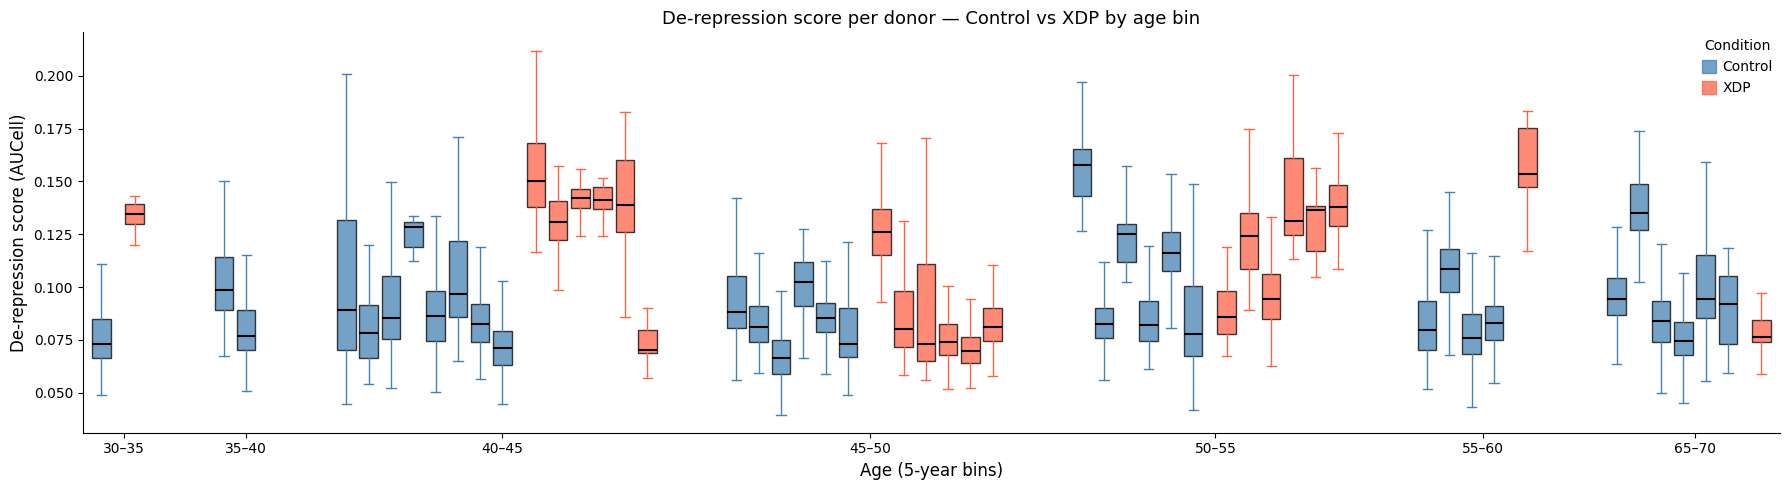

In [34]:
palette = {"Control": "steelblue", "XDP": "tomato"}

AGE_BIN_YEARS       = 5     # bin width in years
GAP_WITHIN_BIN      = 0.6   # gap between donors inside a bin
GAP_BETWEEN_CONDITIONS = 0.3  # extra gap between Control and XDP within a bin
GAP_BETWEEN_BINS    = 1.5   # gap between age bins

plot_df = full_adata.obs[
    [SAMPLE_VARIABLE, "derepressed_score", AGE, CONTRAST_VARIABLE]
].copy()
plot_df[AGE] = plot_df[AGE].astype(float)
plot_df["age_bin"] = (plot_df[AGE] // AGE_BIN_YEARS * AGE_BIN_YEARS).astype(int)

age_bins = sorted(plot_df["age_bin"].unique())

fig, ax = plt.subplots(figsize=(18, 5))

x_pos   = 0
x_ticks = {}

for age_bin in age_bins:
    bin_df    = plot_df[plot_df["age_bin"] == age_bin]
    bin_start = x_pos

    for condition in [CONTRAST_BASELINE, CONTRAST_STIM]:
        cond_df = bin_df[bin_df[CONTRAST_VARIABLE] == condition]
        donors  = (
            cond_df.drop_duplicates(SAMPLE_VARIABLE)
            .sort_values(AGE)[SAMPLE_VARIABLE].tolist()
        )
        color = palette[condition]

        for donor in donors:
            cells = cond_df[cond_df[SAMPLE_VARIABLE] == donor]["derepressed_score"].values
            ax.boxplot(
                cells,
                positions    = [x_pos],
                widths       = 0.5,
                patch_artist = True,
                showfliers   = False,
                medianprops  = dict(color="black", linewidth=1.5),
                boxprops     = dict(facecolor=color, alpha=0.75),
                whiskerprops = dict(color=color),
                capprops     = dict(color=color),
            )
            x_pos += GAP_WITHIN_BIN

        x_pos += GAP_BETWEEN_CONDITIONS   # small gap between the two conditions

    bin_label = f"{age_bin}–{age_bin + AGE_BIN_YEARS}"
    x_ticks[bin_label] = (bin_start + x_pos - GAP_WITHIN_BIN) / 2
    x_pos += GAP_BETWEEN_BINS

ax.set_xticks(list(x_ticks.values()))
ax.set_xticklabels(list(x_ticks.keys()), fontsize=10)
ax.set_xlabel(f"Age ({AGE_BIN_YEARS}-year bins)", fontsize=12)
ax.set_ylabel("De-repression score (AUCell)", fontsize=12)
ax.set_title("De-repression score per donor — Control vs XDP by age bin", fontsize=13)

legend_patches = [mpatches.Patch(color=c, alpha=0.75, label=l) for l, c in palette.items()]
ax.legend(handles=legend_patches, title="Condition", frameon=False)

sns.despine()
plt.tight_layout()
plt.show()


<Axes: xlabel='median_umi', ylabel='pct90_derepressed'>

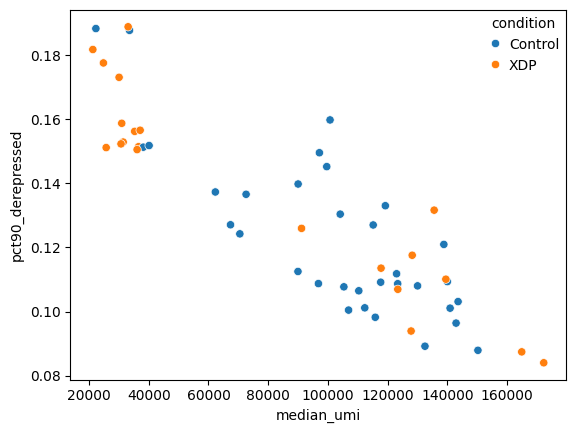

In [37]:
# Is the correlation between median_umi and score driven by NucSeq only, or BICAN too?
import seaborn as sns
sns.scatterplot(data=summary, x="median_umi", y="pct90_derepressed", hue=CONTRAST_VARIABLE)
